In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression, SGDClassifier, LassoCV
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearnex.svm import SVC  # sklearn SVC is too slow
from sklearnex.neighbors import KNeighborsClassifier  # sklearn is too slow
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_sample_weight
from datetime import datetime
import joblib
import dill
import prince
from imblearn.under_sampling import NearMiss, EditedNearestNeighbours
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
import os

pd.options.display.max_columns = None
cur_dir = os.getcwd()

### Preprocessing

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some featurs and transform others.

In [3]:
df.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)

df['day'] = df['time'].dt.day
df['weekday'] = df['time'].dt.weekday
df['hour'] = df['time'].dt.hour
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1])
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 

df.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job', 'merchant'], inplace=True)

Outliers in amount were not completely removed, because significant amount of fraudulent transactions has amount among autliers. That's why I capped amount by 110% of maximum fraudulent transaction.<br/>
Outliers in city_pop and age feature were capped with 1.5 IQR

In [4]:
amount_max = round(df.loc[df['is_fraud'] == 1, 'amount'].max() * 1.1, 2)
df.loc[df['amount'] > amount_max, 'amount'] = amount_max
print('New max amount:', amount_max)

q1 = df['city_pop'].quantile(0.25)
q3 = df['city_pop'].quantile(0.75)
city_pop_max = round(q3 + 1.5 * (q3 - q1))
df.loc[df['city_pop'] > city_pop_max, 'city_pop'] = city_pop_max
print('New max city_pop:', city_pop_max)

q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
age_max = round(q3 + 1.5 * (q3 - q1), 2)
df.loc[df['age'] > age_max, 'age'] = age_max
print('New max age:', age_max)

New max amount: 1513.64
New max city_pop: 49706
New max age: 99.13


In [5]:
df['is_fraud'] = df['is_fraud'].astype(int)
df['amount'] = df['amount'].astype(np.float32)
df['age'] = df['age'].astype(np.float32)

### Feature generation and selection

In [6]:
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

#### Categorical features

Categorical values in the dataset are not ordinal, so they should be one-hot encoded. But this will drastically increase features amount, so I decided to use MCA dimensionality reduction method. The problem with it's implementation in library Prince is it can't accept wanted variability value(like PCA from sklearn) as input, so I need to find the amount of components manually.

In [8]:
print('One-hot produced features:', pd.get_dummies(X_train.select_dtypes(include='object')).shape[1])

One-hot produced features: 73


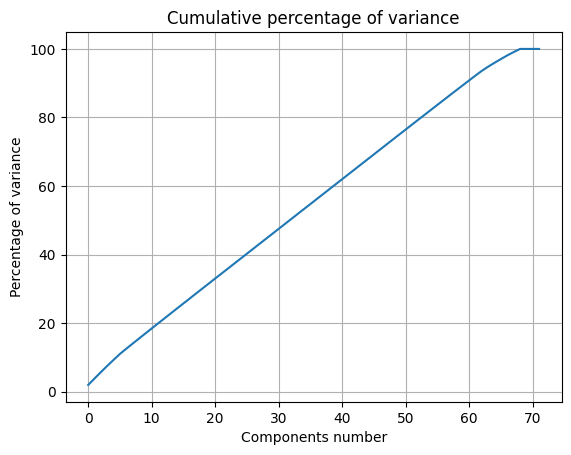

In [9]:
# in current version of prince MCA can't ignore missing values, making it unusable for test dataset. 
# OneHotEncoder is used as a workaround here
one_hot = ColumnTransformer(  
    transformers=[('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=bool), X_train.select_dtypes(include='object').columns)],
        remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

X_train = one_hot.fit_transform(X_train)
X_test = one_hot.transform(X_test)

mca = prince.MCA(n_components=72, random_state=1, one_hot=False)
mca.fit(X_train.select_dtypes(include='bool'))

ax = sns.lineplot(x=range(len(mca.cumulative_percentage_of_variance_)), y=mca.cumulative_percentage_of_variance_)
plt.xlabel('Components number')
plt.ylabel('Percentage of variance')
plt.title('Cumulative percentage of variance')
plt.grid()

68 components represent 100% variance

In [10]:
mca = prince.MCA(n_components=68, random_state=1, one_hot=False)
X_train_cat = mca.fit_transform(X_train.select_dtypes(include='bool'))
X_test_cat = mca.transform(X_test.select_dtypes(include='bool'))

#### Numeric features

Numeric features are used for feature generation by PolynomialFeatures with different degrees. Generated features are compared by scores of LassoCV models.<br/>
4th degree took too much time to compute, so it was decided to reduce the polynomial degree to a manageable level.

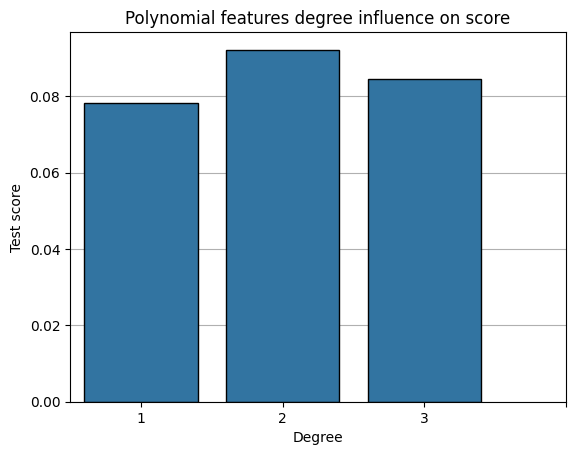

In [11]:
X_train_num_bkp = X_train.select_dtypes(include='number')
X_test_num_bkp = X_test.select_dtypes(include='number')
res = []

for i in range(1, 4):
    pf = PolynomialFeatures(degree=i, include_bias=False)
    X_train = pf.fit_transform(X_train_num_bkp)
    X_test = pf.transform(X_test_num_bkp)
    
    X_train = np.concatenate([X_train, X_train_cat], axis=1)  # mca values are added to estimate features importance
    X_test = np.concatenate([X_test, X_test_cat], axis=1)
    
    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.transform(X_test)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    lasso = LassoCV(random_state=1, max_iter=10**9)  # can't use float32 beacause of sklearn bug
    lasso.fit(X_train, y_train, sample_weight=sample_weights)
    
    pred = lasso.predict(X_test)    
    pred = (pred > 0.5).astype(int)  # transforming probabilities into 0/1 for scoring
    res.append(f1_score(y_test, pred))    

    joblib.dump(lasso, cur_dir + '\\saves\\features_selection\\degree_' + str(i) + '.pkl')  # trained model is stored for future coefficients extraction
    
sns.barplot(x=list(range(1, len(res)+1)), y=res, edgecolor='black', zorder=2)
plt.xlabel('Degree')
plt.ylabel('Test score')
plt.title('Polynomial features degree influence on score')
plt.xticks(range(len(res) + 1))
plt.grid(axis='y')

del X_train_num_bkp
del X_test_num_bkp

Best result was provided by polynomial features of 2nd degree.

#### Feature selection

To select most important features, coefficients of most successful Lasso model from the end of previous section are used. The plot below shows rise of percentage of coefficients' values with number of features.

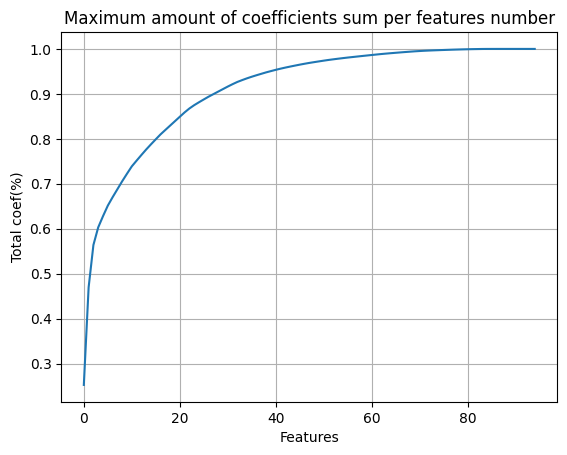

In [10]:
lasso = joblib.load(cur_dir + '\\saves\\features_selection\\degree_2.pkl')

df_coef = pd.DataFrame()
df_coef['coef'] = np.abs(lasso.coef_)  # coefficient sign doesn't matter
df_coef['coef'] = df_coef['coef']/df_coef['coef'].sum()  # for easier interpretation coefficients are translated to parts of 1(sum of all coefficients)

df_coef = df_coef.sort_values(by='coef', ascending=False)  # sorting to get features with biggest importance at the beginning of the list

sns.lineplot(y=df_coef['coef'].cumsum(), x=range(df_coef.shape[0]))
plt.xlabel('Features')
plt.ylabel('Total coef(%)')
plt.title('Maximum amount of coefficients sum per features number')
plt.grid()

60 features make almost 100% contribution.<br/>
Now data for resampling testing can be prepared, besed on previous discoveries.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)
del df

In [12]:
X_train = one_hot.transform(X_train)
X_test = one_hot.transform(X_test)

In [13]:
pf_mca = ColumnTransformer(
    transformers=[('pf', PolynomialFeatures(degree=2, include_bias=False), X_train.select_dtypes(include='number').columns),
                  ('mca', prince.MCA(n_components=68, random_state=1, one_hot=False), X_train.select_dtypes(include='bool').columns)],
        remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

X_train = pf_mca.fit_transform(X_train)
X_test = pf_mca.transform(X_test)

In [14]:
feature_idx = df_coef.iloc[:60, 0].index  # index represents features' sequence in the dataset

X_train = X_train.iloc[:, feature_idx].to_numpy().astype(np.float32)  # reducing from float64 to save time and memory
X_test = X_test.iloc[:, feature_idx].to_numpy().astype(np.float32)

del df_coef

In [15]:
scaler = StandardScaler()
        
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Handling imbalanced data

To handle target class imbalance I test different resampling methods with different models.<br/>
At first data is resampled, then a model is trained using cross validation and score is taken. After this the model is evaluated on test dataset by several metrics to get the idea of general performance.<br/>
For each resampling method a plot is generated showing scores on training and test tets.

Loaded scores for NoResampling


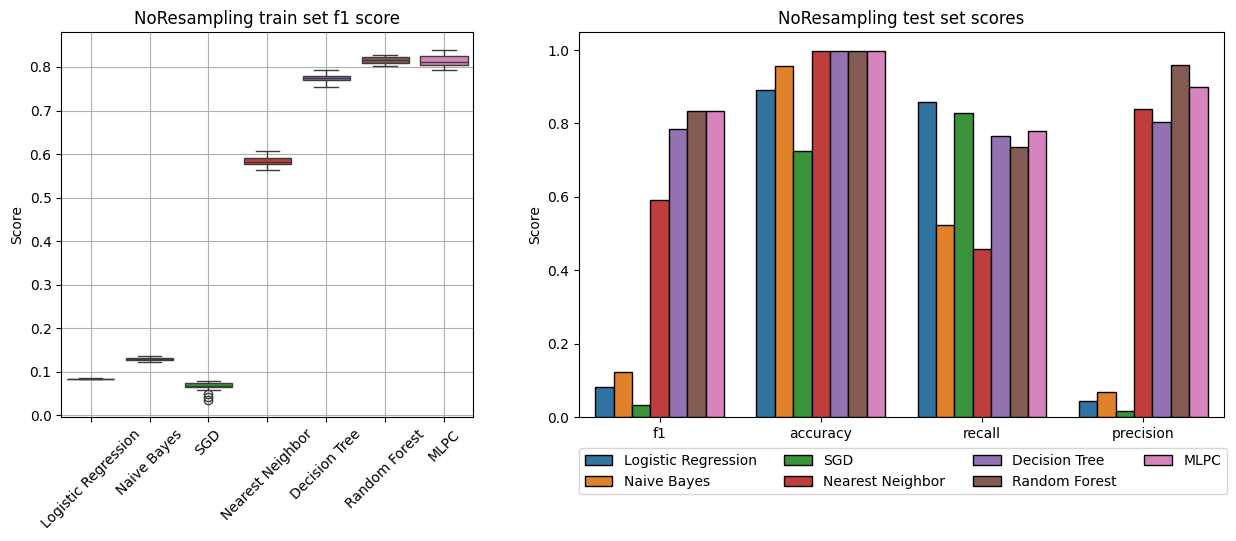

Loaded scores for NearMiss


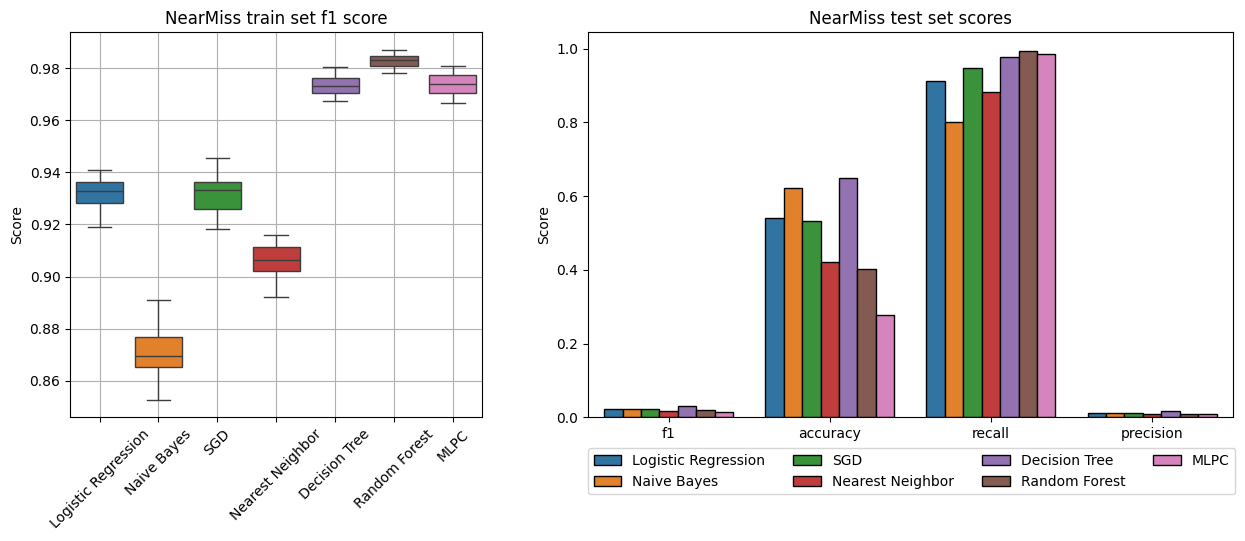

Loaded scores for EditedNearestNeighbours


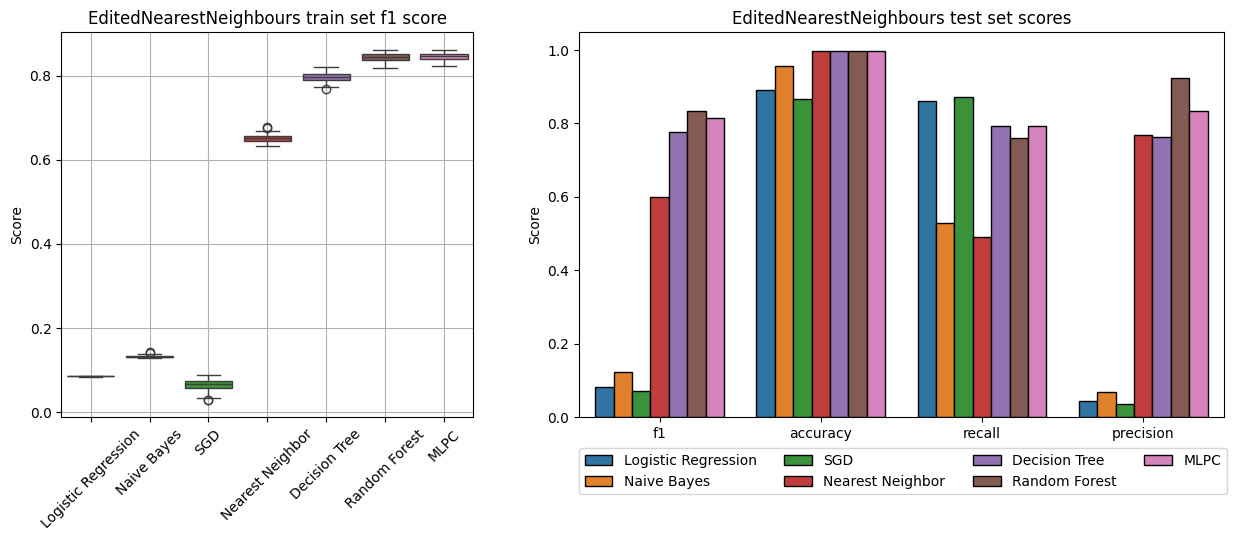

Loaded scores for RandomOverSampler


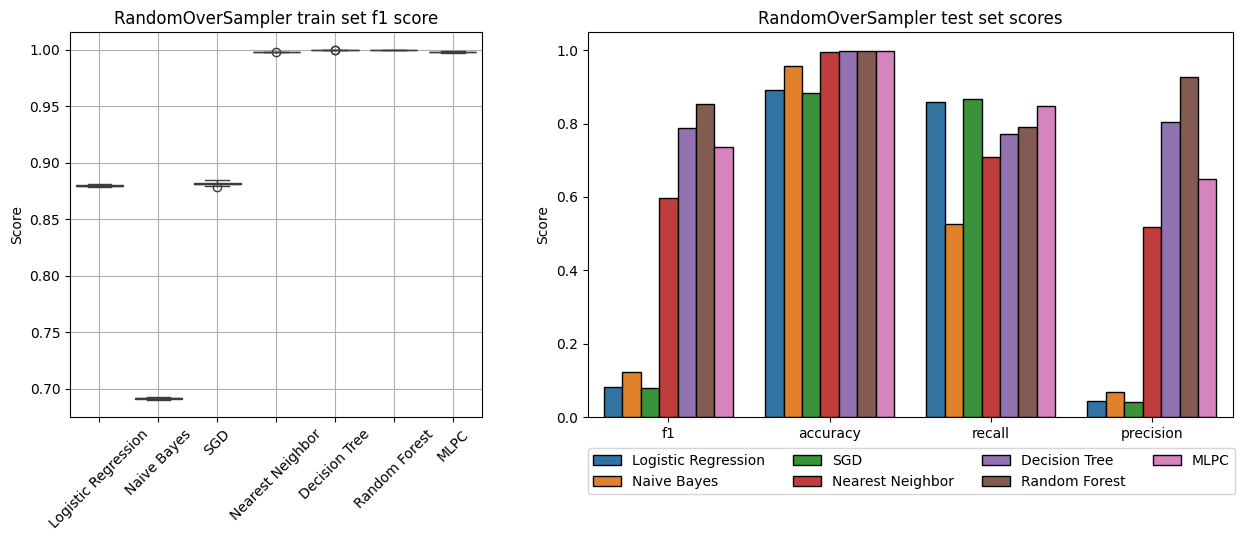

Loaded scores for SMOTE


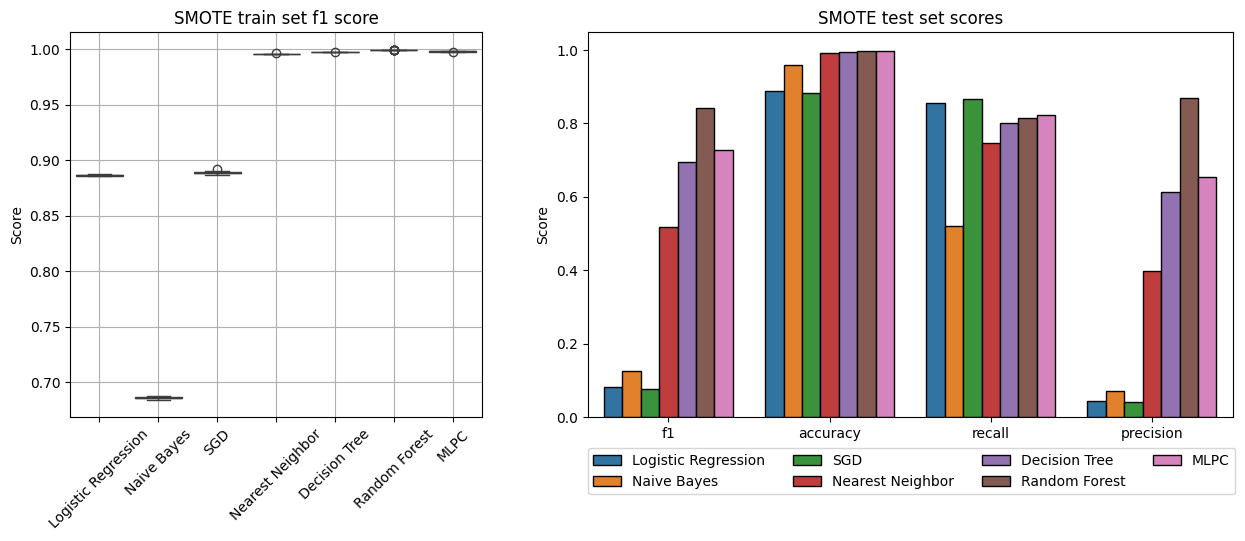

Loaded scores for BSMOTE


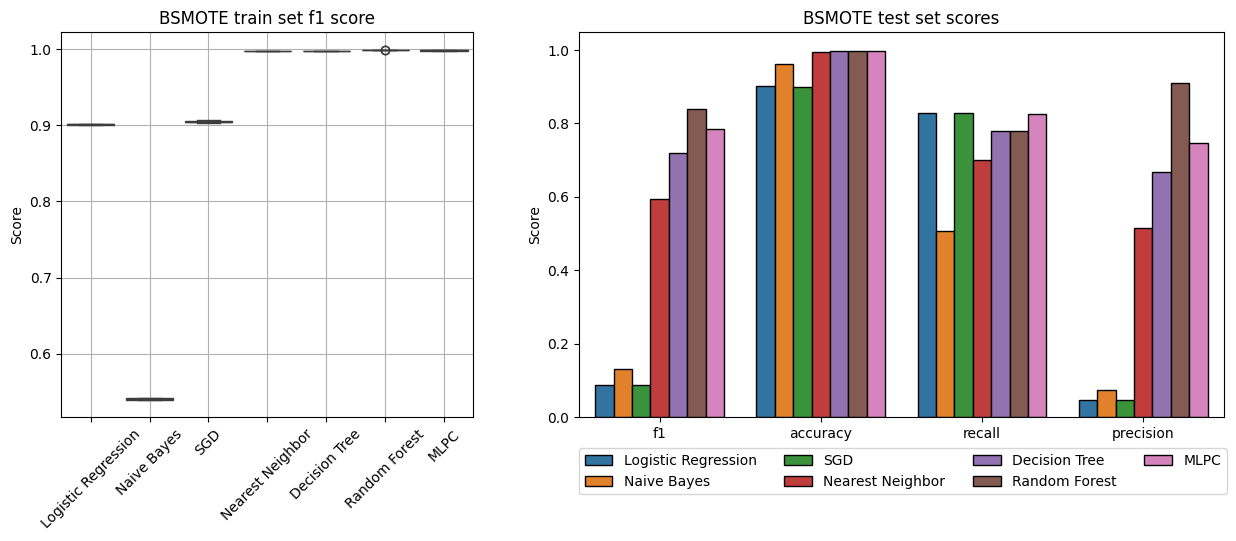

Loaded scores for SMOTETomek


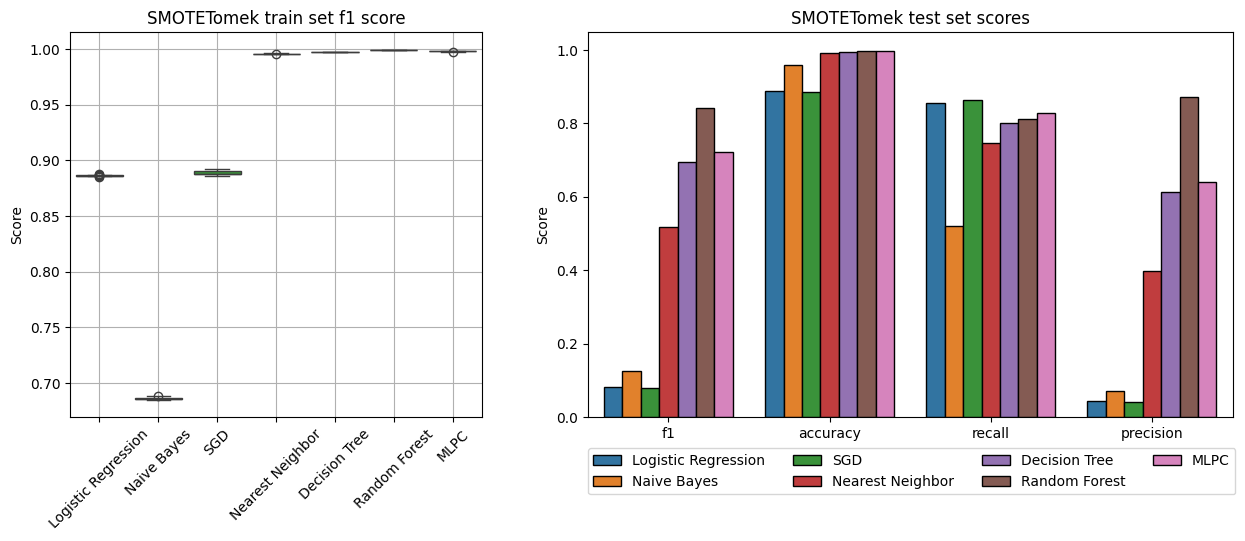

Loaded scores for ADASYN


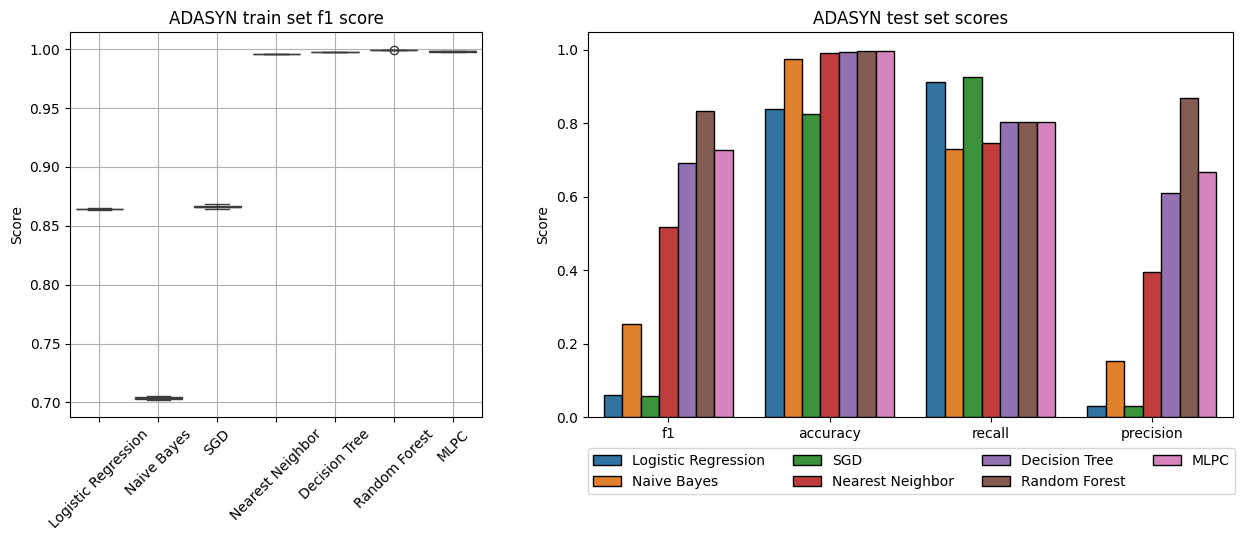

In [18]:
models = {}  # models to be tested
models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=10**9)    
models['Naive Bayes'] = GaussianNB()
#models['SVC'] = SVC(class_weight='balanced', random_state=1, probability=False)  # too slow
models['SGD'] = SGDClassifier(random_state=1)
models['Nearest Neighbor'] = KNeighborsClassifier()
models['Decision Tree'] = DecisionTreeClassifier(random_state=1)
models['Random Forest'] = RandomForestClassifier(random_state=1)
models['MLPC'] = MLPClassifier(random_state=1, max_iter=10**9)

resamplers = {}  # resamplers to be tested
resamplers['NoResampling'] = None
resamplers['NearMiss'] = NearMiss(n_jobs=10)
resamplers['EditedNearestNeighbours'] = EditedNearestNeighbours(n_jobs=10)
resamplers['RandomOverSampler'] = RandomOverSampler(random_state=1)
resamplers['SMOTE'] = SMOTE(random_state=1)
resamplers['BSMOTE'] = BorderlineSMOTE(random_state=1)
resamplers['SMOTETomek'] = SMOTETomek(random_state=1)
resamplers['ADASYN'] = ADASYN(random_state=1)

try:
    saves = joblib.load(cur_dir + '\\saves\\resampling_selection.pkl')  # file that stores testing results for future reuse/adding new data

    train_scores = saves['train_scores']
    test_scores = saves['test_scores']
except:
    train_scores = pd.DataFrame(columns=['sampler', 'model', 'value'])
    test_scores = pd.DataFrame(columns=['sampler', 'model', 'metric', 'value'])
    
    saves = {'train_scores': train_scores, 'test_scores': test_scores}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1)

for name_s, resampler in resamplers.items():
    if name_s in train_scores['sampler'].values:
        print('Loaded scores for', name_s)  # in case this test was done during previous run
    else:
        if resampler:
            print(name_s, datetime.now())
            X_train_tmp, y_train_tmp = resampler.fit_resample(X_train, y_train)
        else:  # for NoResampling
            X_train_tmp = X_train.copy()
            y_train_tmp = y_train.copy()
        
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_tmp)
        
        for name_m, model in models.items():
            print(name_m, datetime.now())
            
            gs = GridSearchCV(model, cv=cv, n_jobs=5, param_grid={}, scoring='f1')
            
            if name_m in ['Nearest Neighbor', 'MLPC']:  # these algorithms don't have sample_weight parameter
                gs.fit(X_train_tmp, y_train_tmp)
            else:
                gs.fit(X_train_tmp, y_train_tmp, sample_weight=sample_weights)
            
            pred = gs.predict(X_test)
            
            test_scores.loc[len(test_scores.index)] = [name_s, name_m, 'f1', f1_score(y_test, pred)]
            test_scores.loc[len(test_scores.index)] = [name_s, name_m, 'accuracy', accuracy_score(y_test, pred)]
            test_scores.loc[len(test_scores.index)] = [name_s, name_m, 'recall', recall_score(y_test, pred)]
            test_scores.loc[len(test_scores.index)] = [name_s, name_m, 'precision', precision_score(y_test, pred)]
    
            scores = []
            for i in range(cv.get_n_splits()):
                train_scores.loc[len(train_scores.index)] = [name_s, name_m, gs.cv_results_['split' + str(i) + '_test_score'][0]]
    
        joblib.dump(saves, cur_dir + '\\saves\\resampling_selection.pkl') 
    
        print(datetime.now())    
    
    fig, (box, bar) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": (0.39, 0.61)})
    
    sns.boxplot(data=train_scores[train_scores['sampler'] == name_s], x='model', y='value', hue='model', ax=box).set_title(name_s + ' train set f1 score')
    box.set_xlabel('')
    box.set_ylabel('Score')
    box.tick_params(axis='x', labelrotation = 45)
    box.grid()
    
    sns.barplot(data=test_scores[test_scores['sampler'] == name_s], x='metric', y='value', hue='model', ax=bar, edgecolor='black').set_title(name_s + ' test set scores')
    plt.legend(bbox_to_anchor=(0, -0.2), loc='lower left', borderaxespad=0, ncol=4)
    bar.set_xlabel('')
    bar.set_ylabel('Score')
    
    plt.show()

All resampling methods, except EditedNearestNeighbours make models overfit without noticeable increase of scores on the test set. So, only EditedNearestNeighbours and NoResampling can be taken into consideration.<br/>
A plot showing scores for test set of 4 top performing models will help to select the best resampling method.

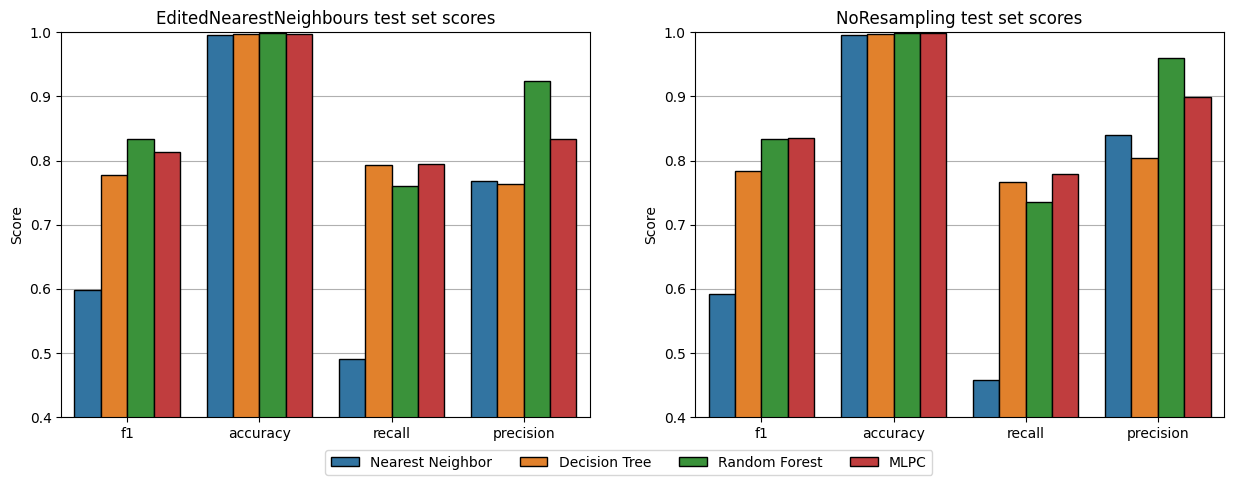

In [19]:
df_select = test_scores[test_scores['sampler'].isin(['EditedNearestNeighbours', 'NoResampling']) & 
                  ~test_scores['model'].isin(['Logistic Regression', 'Naive Bayes', 'SGD'])]

fig, (bar1, bar2) = plt.subplots(1, 2, figsize=(15, 5))
    
sns.barplot(data=df_select[df_select['sampler'] == 'EditedNearestNeighbours'], x='metric', y='value', hue='model', ax=bar1, edgecolor='black', zorder=2)
bar1.set_title('EditedNearestNeighbours test set scores')
bar1.get_legend().remove()
bar1.set_ylim([0.4, 1])
bar1.set_xlabel('')
bar1.set_ylabel('Score')
bar1.grid(axis='y')

sns.barplot(data=df_select[df_select['sampler'] == 'NoResampling'], x='metric', y='value', hue='model', ax=bar2, edgecolor='black', zorder=2)
bar2.set_title('NoResampling test set scores')
plt.legend(bbox_to_anchor=(-0.7, -0.15), loc='lower left', borderaxespad=0, ncol=4)
bar2.set_ylim([0.4, 1])
bar2.set_xlabel('')
bar2.set_ylabel('Score')
bar2.grid(axis='y')

NoResampling shows a bit higher scores for target f1 score, except for Nearest Neighbor. It also has higher precision at cost of recall.<br/>
Resampling methods showed no improvement on the dataset, so no resampling will be used further.

### Preprocessing pipeline

The result of Preprocessing will be a data preprocessing pipeline, that will perform all data preparation and can be used in model training later.

In [20]:
class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, amount_max, city_pop_max, age_max):
        self.amount_max = amount_max
        self.city_pop_max = city_pop_max
        self.age_max = age_max
    
    def fit(self, *args, **kwargs):
        return self

    def set_output(self, *args, **kwargs):
        pass
    
    def transform(self, X, *args, **kwargs):
        X.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)
        # new features
        X['day'] = X['time'].dt.day
        X['weekday'] = X['time'].dt.weekday
        X['hour'] = X['time'].dt.hour
        X['industry_code'] = X['cc_num'].astype(str).apply(lambda x: x[0:1])
        X['age'] = (pd.to_datetime('today') - pd.to_datetime(X['dob'])).dt.days/365.25 
        # dropping features
        X.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 
                        'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job', 'merchant'], inplace=True)        
        # outliers
        X.loc[X['amount'] > self.amount_max, 'amount'] = self.amount_max   
        X.loc[X['city_pop'] > self.city_pop_max, 'city_pop'] = self.city_pop_max
        X.loc[X['age'] > self.age_max, 'age'] = self.age_max
        # dtypes update
        X['amount'] = X['amount'].astype(np.float32)
        X['age'] = X['age'].astype(np.float32)
        
        return X

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_idx):
        self.feature_idx = feature_idx  # sequential numbers of featrures in dataset
    
    def fit(self, *args, **kwargs):
        return self

    def set_output(self, *args, **kwargs):
        pass
    
    def transform(self, X, *args, **kwargs):   
        return X.iloc[:, self.feature_idx].to_numpy().astype(np.float32)

pipe = Pipeline([('preprocessor', Preprocessor(amount_max, city_pop_max, age_max)), 
                  ('one_hot', one_hot),
                  ('pf_mca', pf_mca),  
                  ('selector', FeatureSelector(feature_idx)),
                  ('scaler', scaler)
                 ])

#pipe

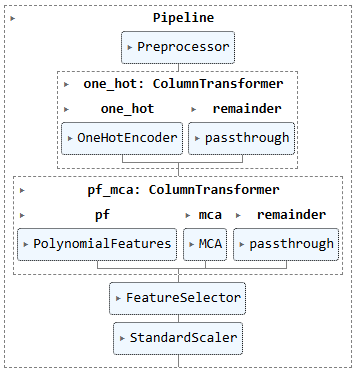

Saving the pipepline for using in the future.

In [17]:
with open(cur_dir + '\\saves\\preprocessing_pipeline.dill', 'wb') as file:  # dill enables pickling custom transformers
    dill.dump(pipe, file)
del pipe

To test the pipeline I use it on newly loaded data.

In [18]:
with open(cur_dir + '\\saves\\preprocessing_pipeline.dill', 'rb') as file:
    pipe_test = dill.load(file)

pipe_test_df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
pipe_test_y = pipe_test_df['is_fraud']
pipe_test_df.drop(columns='is_fraud', inplace=True)

If everything is done correctly, data from the pipeline is equal to the data used during  resampling selection.

In [19]:
pipe_test_df = pipe_test.transform(pipe_test_df)
pipe_test_X_train, pipe_test_X_test, pipe_test_y_train, pipe_test_y_test = train_test_split(pipe_test_df, pipe_test_y, test_size=0.25, random_state=1, stratify=pipe_test_y)

print('Train sets equal:', np.allclose(X_train, pipe_test_X_train, atol=1e-50))
print('Test sets equal:', np.allclose(X_test, pipe_test_X_test, atol=1e-50))

Train sets equal: True
Test sets equal: True
